# Exploratory Data Analysis: `data/train.parquet`

This notebook explores the training split for an NLP summarization-style dataset. It focuses on schema checks, missing values, duplicate rows, text lengths, article-to-summary ratios, and frequent tokens.

## Setup

If the imports fail, run the install cell below once, then restart the notebook kernel.

In [1]:
# Uncomment and run if your environment does not have these packages installed.
# %pip install pandas pyarrow matplotlib seaborn

In [2]:
from pathlib import Path
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

## Load Data

In [3]:
def find_data_path(filename: str) -> Path:
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("..") / "data" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename}. Tried: {candidates}")

train_path = find_data_path("train.parquet")
train_path

PosixPath('../data/train.parquet')

In [4]:
df = pd.read_parquet(train_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())

Rows: 10,775
Columns: 2


,article,summary
0,"Gần 20 sự kiện được tổ chức trên toàn thành phố, kéo dài từ 19/4 đến 10/5. Theo Sở Du lịch Hà Nội, ngoài thu hút du khách, loạt sự kiện cũng là các gợi ý dà...","Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5, bao gồm Lễ hội Du lịch Hà Nội 2024, các triển lãm và lễ hội văn hóa, nhằm thu hút cả du khách và người dân. ..."
1,"Được thành lập năm 1897 tại Đức, Kempinski Hotels là thương hiệu nổi tiếng trong lĩnh vực nghỉ dưỡng, được sở hữu bởi hai hoàng gia Trung Đông và châu Á. Tr...","Kempinski Hotels là một thương hiệu nổi tiếng trong lĩnh vực nghỉ dưỡng, được thành lập năm 1897 tại Đức. Với hơn 127 năm lịch sử, Kempinski đã trở thành đi..."
2,"Ngoài di chuyển đến Tuần Châu bằng đường bộ, mọi người có thể thử đi phà. Bến phà Tuần Châu nằm ngay trung tâm Bãi Cháy, thuận tiện trong lịch trình. Một tr...","Bài viết giới thiệu các hoạt động vui chơi giải trí tại Tuần Châu dịp 30/4, bao gồm đi phà đến đảo, tham quan Harmony Hill với mini show ""Sóng Tình"" của ca ..."
3,"Với những tín đồ Phật giáo, bức tượng Phật ngọc hòa bình thế giới được biết đến là tín vật thuộc sở hữu của vợ chồng ông Ian Green và bà Judy Green người Au...","Bức tượng Phật ngọc hòa bình thế giới, được vợ chồng ông Ian Green sở hữu, là pho tượng Phật ngọc lớn nhất thế giới, được tạc tại Thái Lan dựa theo tượng Ph..."
4,"Số liệu của Tổng cục Thống kê công bố sáng 29/4 cho thấy Hàn Quốc vẫn là thị trường gửi khách lớn nhất đến Việt Nam trong tháng 4 và 4 tháng đầu năm, tiếp t...","Trong tháng 4, Việt Nam tiếp tục đón khách quốc tế với số lượng 1,55 triệu lượt, giảm nhẹ so với tháng 3 nhưng tăng 58,2% so với cùng kỳ năm trước. Tổng số ..."


## Schema and Basic Quality Checks

In [5]:
schema_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "n_unique": df.nunique(dropna=True),
})

schema_summary

,dtype,missing,missing_pct,n_unique
article,str,0,0.0,10775
summary,str,0,0.0,10775


In [6]:
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows:,} ({duplicate_rows / len(df):.2%})")

text_columns = [col for col in ["article", "summary"] if col in df.columns]
for col in text_columns:
    duplicated_text = df[col].duplicated().sum()
    empty_text = df[col].fillna("").str.strip().eq("").sum()
    print(f"{col}: duplicated={duplicated_text:,} ({duplicated_text / len(df):.2%}), empty={empty_text:,}")

Duplicate rows: 0 (0.00%)
article: duplicated=0 (0.00%), empty=0
summary: duplicated=0 (0.00%), empty=0


## Text Length Features

In [7]:
def word_count(series: pd.Series) -> pd.Series:
    return series.fillna("").str.findall(r"\b\w+\b").str.len()

eda = df.copy()

if "article" in eda.columns:
    eda["article_chars"] = eda["article"].fillna("").str.len()
    eda["article_words"] = word_count(eda["article"])

if "summary" in eda.columns:
    eda["summary_chars"] = eda["summary"].fillna("").str.len()
    eda["summary_words"] = word_count(eda["summary"])

if {"article_words", "summary_words"}.issubset(eda.columns):
    eda["summary_to_article_word_ratio"] = eda["summary_words"] / eda["article_words"].replace(0, pd.NA)

length_cols = [col for col in eda.columns if col.endswith(("_chars", "_words")) or col.endswith("_ratio")]
eda[length_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
article_chars,10775.0,2128.281578,464.814019,1286.000000,1394.000000,1484.000000,1768.000000,2061.000000,2402.500000,3042.000000,3232.000000,3580.00000
article_words,10775.0,462.993132,99.882899,280.000000,306.000000,323.000000,386.000000,449.000000,520.000000,662.000000,696.000000,737.00000
summary_chars,10775.0,469.676566,99.068855,222.000000,279.000000,323.000000,396.000000,458.000000,540.000000,645.000000,694.000000,792.00000
summary_words,10775.0,103.769838,21.886020,50.000000,62.000000,71.000000,87.000000,101.000000,119.000000,143.000000,152.000000,172.00000
summary_to_article_word_ratio,10775.0,0.231854,0.060206,0.081288,0.120397,0.143008,0.187255,0.226415,0.270169,0.340511,0.390917,0.48495


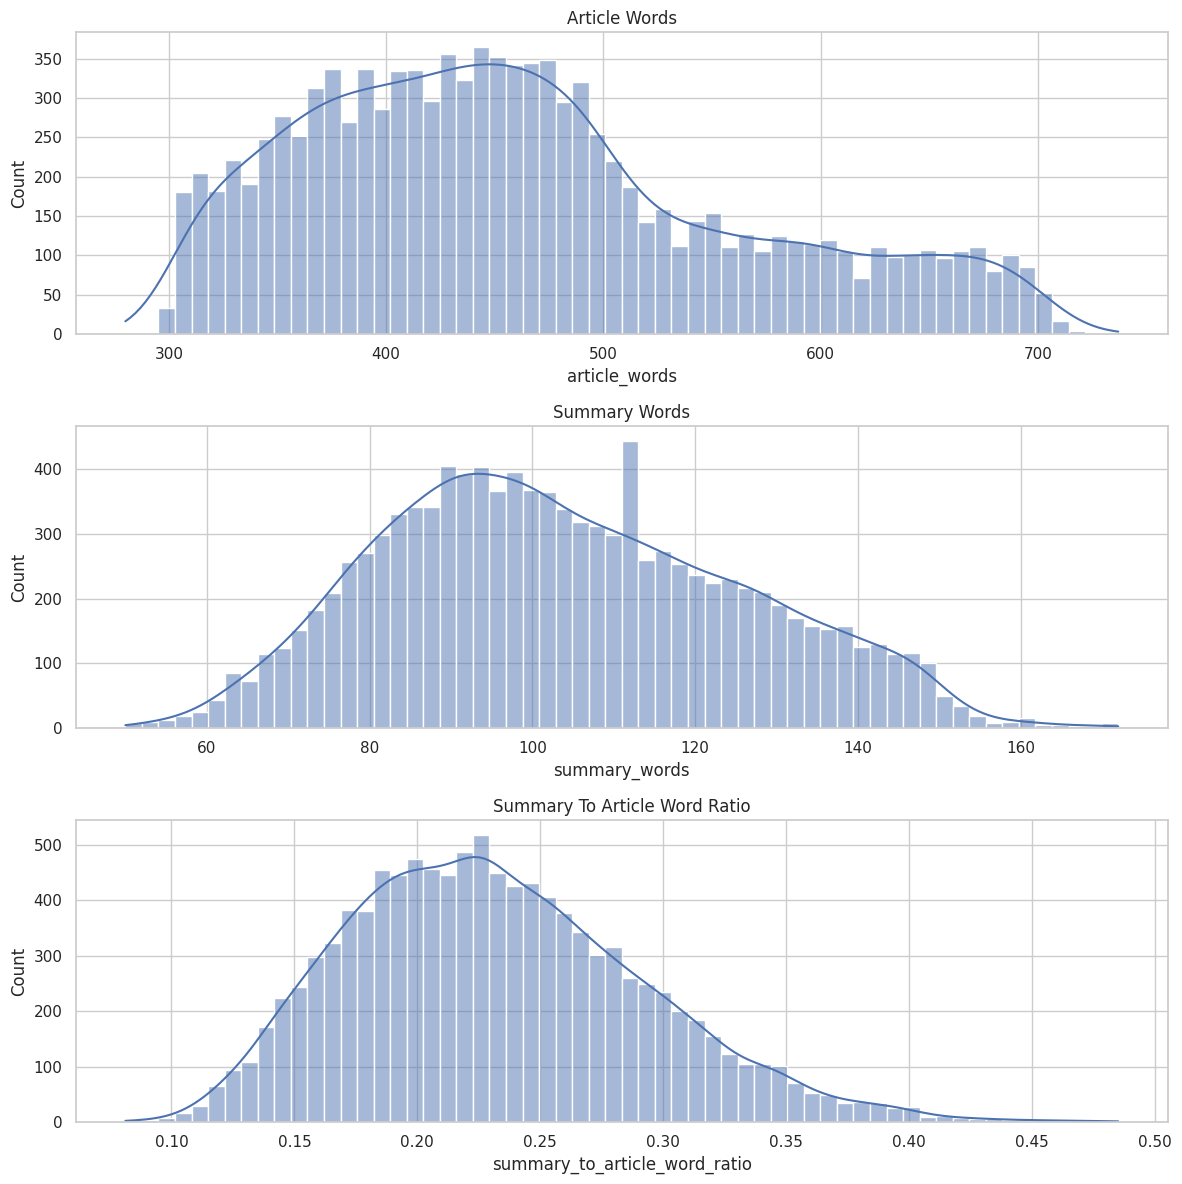

In [8]:
plot_cols = [col for col in ["article_words", "summary_words", "summary_to_article_word_ratio"] if col in eda.columns]

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(12, 4 * len(plot_cols)))
if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    sns.histplot(eda[col].dropna(), bins=60, kde=True, ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col)

plt.tight_layout()

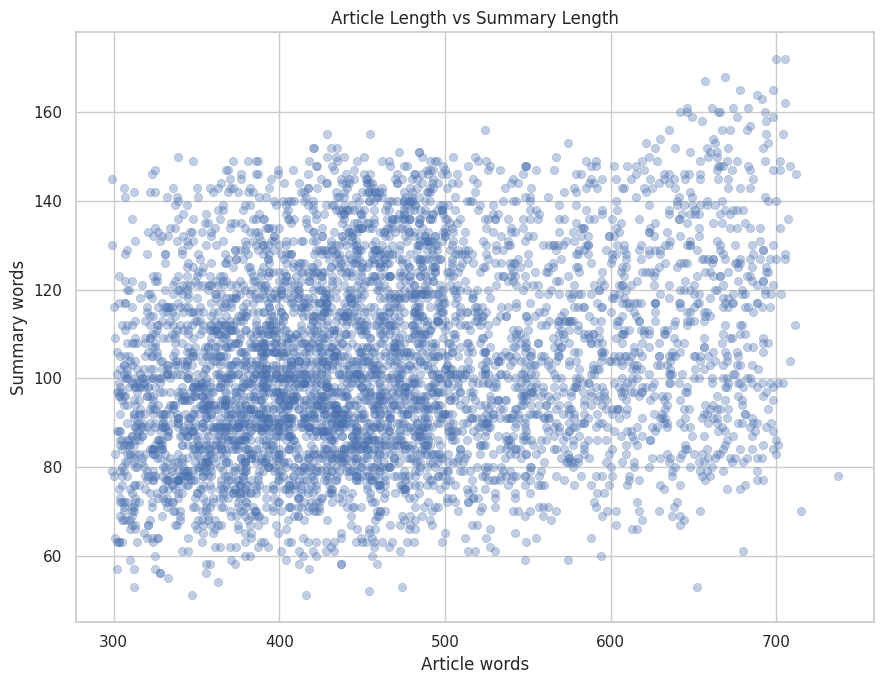

In [9]:
if {"article_words", "summary_words"}.issubset(eda.columns):
    sample_size = min(5000, len(eda))
    sampled = eda.sample(sample_size, random_state=42) if len(eda) > sample_size else eda

    plt.figure(figsize=(9, 7))
    sns.scatterplot(data=sampled, x="article_words", y="summary_words", alpha=0.35, edgecolor=None)
    plt.title("Article Length vs Summary Length")
    plt.xlabel("Article words")
    plt.ylabel("Summary words")
    plt.tight_layout()

## Extreme Examples

Reviewing very short, very long, and unusual compression-ratio examples helps catch parsing issues and annotation noise.

In [10]:
preview_cols = [col for col in ["article_words", "summary_words", "summary_to_article_word_ratio", "article", "summary"] if col in eda.columns]

def show_examples(title: str, rows: pd.DataFrame, n: int = 5) -> None:
    print(title)
    display(rows[preview_cols].head(n))

if "article_words" in eda.columns:
    show_examples("Shortest articles", eda.sort_values("article_words"))
    show_examples("Longest articles", eda.sort_values("article_words", ascending=False))

if "summary_to_article_word_ratio" in eda.columns:
    show_examples("Lowest summary/article ratios", eda.sort_values("summary_to_article_word_ratio"))
    show_examples("Highest summary/article ratios", eda.sort_values("summary_to_article_word_ratio", ascending=False))

Shortest articles


,article_words,summary_words,summary_to_article_word_ratio,article,summary
2961,280,88,0.314286,"1. Either... or...: ""hoặc... hoặc..."" - Dùng với nghĩa khẳng định, mang ý nghĩa hai sự vật/sự việc đều có thể xảy ra, tùy vào ngữ cảnh để chọn hoặc đề cập đ...","Câu ""Either... hoặc..."" và ""Neither... cũng không..."" là hai cấu trúc được sử dụng để diễn đạt ý nghĩa khẳng định và phủ định hoàn toàn. Cấu trúc của chúng ..."
969,296,108,0.364865,"Sau nhiều năm ngưng ca hát, Trương Thế Vinh gây chú ý khi trở lại tại show âm nhạc Anh trai vượt ngàn chông gai . Anh nói tìm thấy nhiều niềm hứng khởi, đượ...",Trương Thế Vinh đã trở lại sau nhiều năm ngưng ca hát tại show âm nhạc Anh trai vượt ngàn chông gai. Anh nói đã tìm thấy nhiều niềm hứng khởi và được khơi d...
2015,297,98,0.329966,"Hôm 19/6, tại sự kiện, Suri Cruise trông rạng rỡ với đầm họa tiết kiểu boho, thân trên cảm hứng từ corset. Cô kết hợp đầm cùng clutch màu đen đơn giản, sand...","Suri Cruise, 18 tuổi, gây ấn tượng với phong cách thời trang quý cô gợi cảm hiếm thấy trong sự kiện ngày 19/6. Con gái Tom Cruise và Katie Holmes dự định t..."
2432,298,111,0.372483,"Theo digiqualia , Clio Newton sắp mở triển lãm từ ngày 18/1 đến 2/3 tại Forum Gallery (New York, Mỹ), giới thiệu tác phẩm. Các bức tranh mới của Clio không ...","Clio Newton, một nữ nghệ sĩ nổi tiếng, sắp tổ chức triển lãm tại Forum Gallery ở New York từ ngày 18/1 đến 2/3. Cô nổi tiếng với các bức tranh chân dung phụ..."
1430,299,79,0.264214,"Theo trang MK , trong chương trình truyền hình với MC Yoo Jae Seok, ông Song Young Kwan - một trong hai người chăm sóc Fu Bao - cho biết phim về gấu trúc nổ...","Gấu trúc Fu Bao, một gấu trúc nổi tiếng, đã kết thúc chương trình chăm sóc tại Hàn Quốc và hiện đang ở Trung tâm Nghiên cứu và Bảo tồn gấu trúc ở tỉnh Tứ Xu..."


Longest articles


,article_words,summary_words,summary_to_article_word_ratio,article,summary
2147,737,78,0.105834,"BST trang phục thể thao mới Hugo x RB kết hợp hai lĩnh vực đua xe và thời trang, thôi thúc người mặc thể hiện cá tính cả trong lẫn ngoài đườn...","BST trang phục thể thao mới Hugo x RB kết hợp giữa đua xe và thời trang, với hai tay đua Daniel Ricciardo và Yuki Tsunoda làm người mẫu. Lấy cảm hứng từ giả..."
2172,722,111,0.153740,"Natalie Portman nằm trong số những ngôi sao theo đuổi mốt này. Minh tinh chọn đầm lưới tạo nên từ các mắt xích siêu nhỏ của Dior, nhấn vào tay bồng khi tới ...","Mốt ""Medieval Weird Core"" hoặc ""Weirdeval"" đang trở nên phổ biến ở các sự kiện thời trang, lấy cảm hứng từ thời Trung cổ. Các thiết kế thường có màu bạc, ch..."
9303,720,112,0.155556,"Việt Nam nằm trong nhóm bốn đội toàn thắng, sau năm vòng bảng Mở rộng Olympiad 2024, và được nền tảngChessví như ""sát thủ của những ông lớn"". Trong đó, Trườ...","Nhóm bốn đội toàn thắng tại Olympiad 2024, Việt Nam nằm trong số đó, được đánh giá là ""sát thủ của những ông lớn"". Trường Sơn (Elo 2.633) đã thể hiện ấn tượ..."
2204,716,112,0.156425,"TheoVogue, sự trở lại của thời trang những năm 1970 kéo theo sự bùng nổ doanh số quần nhung trên các nền tảng thương mại điện tử. Các cửa hàng tại châu Âu, ...","Xu hướng quần nhung đã trở lại mạnh mẽ trong thời trang năm nay. TheoVogue, doanh số quần nhung trên các nền tảng thương mại điện tử đã tăng cao, với nhiều ..."
1134,716,127,0.177374,"Nghệ sĩ dự một sự kiện ở Hà Nội chiều 9/11, trong lần thứ ba đến Việt Nam. Những lần trước, anh đi chụp tạp chí hoặc làm từ thiện. Anh nói mong muốn tham gi...","Nghệ sĩ Song Seung Heon dự sự kiện ở Hà Nội chiều 9/11, lần thứ ba đến Việt Nam. Anh mong muốn tham gia dự án phim hợp tác Việt - Hàn và cho biết vẫn tin và..."


Lowest summary/article ratios


,article_words,summary_words,summary_to_article_word_ratio,article,summary
6682,652,53,0.081288,"Tổng thu nhập của vợ chồng cũng vào khoảng trăm triệu đồng, mà mỗi tháng chi tiêu không quá 10 triệu đồng, có tháng chỉ hơn 5 triệu đồng. Tôi đi làm mang th...","Tổng thu nhập của vợ chồng của Lê Thành Đô vào khoảng trăm triệu đồng, mỗi tháng chi tiêu không quá 10 triệu đồng, có tháng chỉ hơn 5 triệu đồng. Vợ chồng L..."
1344,673,55,0.081724,"Cây bút xứ Quảng là một trong 10 đại sứ năm nay, đồng hành chương trình diễn ra từ ngày 17 đến 22/4. Ban tổ chức đánh giá sự tham gia của nhà văn đóng góp l...","Cây bút xứ Quảng là một trong 10 đại sứ năm nay, đồng hành chương trình diễn ra từ ngày 17 đến 22/4. Ban tổ chức đánh giá sự tham gia của nhà văn đóng góp l..."
2068,615,54,0.087805,"Sáng 3/8, Lisa chia sẻ trên trang cá nhân bức ảnh du lịch ở châu Âu. Cô mang dép bệt tối giản với bộ váy áo màu be của Louis Vuitton, túi đeo vai kiểu thập ...","Sau khi ra mắt MVRockstar, Lisa dành thời gian du lịch ở châu Âu. Cô thường xuyên mặc áo phông mini dáng ngắn, xu hướng được ưa chuộng hè năm nay. Ngoài ra,..."
9692,634,56,0.088328,"Theo báo ĐứcBild, Van de Velde sẽ không ở cùng các VĐV khác trong làng Olympic như truyền thống, như sẽ chọn nơi ở khác tại Paris. Đồng đội của Van de Velde...","ôle Van de Velde sẽ không ở cùng các VĐV khác trong làng Olympic như truyền thống, như sẽ chọn nơi ở khác tại Paris. Đồng đội của Van de Velde trong tuyển b..."
1124,654,58,0.088685,"Hai ngày sau khi đón con - bé Dustin,Quang Minhcòn nguyên cảm giác xúc động. Trước đó, càng gần đến ngày dự sinh, anh nói càng hồi hộp bởi có con khi tuổi đ...","Quang Minh cho biết, khi gặp Khánh Chi, anh đã nhận ra tình cảm sâu đậm dành cho cô và ngược lại. Anh không dự định tổ chức lễ kết hôn vì quan niệm cưới hỏi..."


Highest summary/article ratios


,article_words,summary_words,summary_to_article_word_ratio,article,summary
9058,299,145,0.484950,"Theo thông báo của nhà chức trách Pháp ngày 23/7, nghi phạm sinh năm 1984, bị giữ tại Paris vì tội ""tổ chức các hoạt động có khả năng gây bất ổn trong thời ...","Tại Pháp, một nghi phạm đã bị bắt giữ vì tội tổ chức các hoạt động có khả năng gây bất ổn trong thời gian diễn ra Thế vận hội Paris 2024. Cảnh sát đã đột kí..."
1293,306,147,0.480392,"Sách gồm 816 trang, tổng hợp 90 bài viết, bài nói, trả lời phỏng vấn của Đại tướngPhan Văn Giang, được sắp xếp theo nhóm chủ đề phù hợp với trình tự thời gi...","Sách ""Đại tướng Phan Văn Giang"" gồm 816 trang, tổng hợp 90 bài viết, bài nói, trả lời phỏng vấn của Đại tướng Phan Văn Giang. Tác phẩm được sắp xếp theo nhó..."
4840,304,146,0.480263,"Cụ thể, tối ngày 26/7, đoàn công tác phối hợp Quận đoàn Liên Chiểu, Hội Cựu chiến binh tổ chức lễ dâng hương tưởng niệm, thắp nến, hoa đăng tri ân các Anh h...","Đoàn công tác phối hợp giữa Quận đoàn Liên Chiểu, Hội Cựu chiến binh đã tổ chức lễ dâng hương tưởng niệm, thắp nến, hoa đăng tri ân các Anh hùng liệt sĩ tại..."
10173,308,146,0.474026,"Quyết định kỷ luật ông Nguyễn Đình Tiến được Tỉnh ủy Gia Lai công bố hôm 11/10. Ông Tiến là Bí thư Đảng ủy, Giám đốc Sở Nội vụ (giai đoạn 2020 - 2023), chịu...","Tỉnh ủy Gia Lai đã công bố quyết định kỷ luật ông Nguyễn Đình Tiến, cựu Bí thư Đảng ủy và Giám đốc Sở Nội vụ Gia Lai. Ông Tiến chịu trách nhiệm về những vi ..."
876,301,141,0.468439,"Rolls-Royce vừa khai trương ""văn phòng riêng"" (Private Office) ở New York - một dạng studio thiết kế xe theo yêu cầu đầu tiên ở Bắc Mỹ, thị trường lớn nhất ...","Rolls-Royce vừa khai trương ""văn phòng riêng"" (Private Office) tại New York, thị trường lớn nhất của hãng trong hai thập kỷ qua. Văn phòng này nằm ở quận Me..."


## Frequent Tokens

This uses a light tokenizer and a small stopword list to quickly inspect common content words without adding extra NLP dependencies.

In [11]:
STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has", "he", "in", "is", "it",
    "its", "of", "on", "that", "the", "to", "was", "were", "will", "with", "this", "these", "those",
    "or", "not", "but", "they", "their", "his", "her", "she", "you", "we", "our", "have", "had", "been"
}

def tokenize_text(values: pd.Series, max_rows: int = 20000) -> list[str]:
    sample = values.dropna().astype(str).head(max_rows)
    tokens = []
    for text in sample:
        tokens.extend(
            token for token in re.findall(r"\b[a-zA-Z][a-zA-Z']+\b", text.lower())
            if token not in STOPWORDS and len(token) > 2
        )
    return tokens

def top_tokens(values: pd.Series, n: int = 25) -> pd.DataFrame:
    counts = Counter(tokenize_text(values))
    return pd.DataFrame(counts.most_common(n), columns=["token", "count"])

token_tables = {}
for col in text_columns:
    token_tables[col] = top_tokens(df[col])
    display(token_tables[col].style.set_caption(f"Top tokens: {col}"))

,token,count
0,trong,42630
1,cho,34056
2,khi,26204
3,theo,17500
4,sau,16617
5,hai,14443
6,anh,13671
7,gia,12884
8,cao,11085
9,nam,11067


,token,count
0,trong,9110
1,cho,7819
2,khi,4753
3,sau,3709
4,gia,3260
5,nam,3188
6,cao,2873
7,hai,2698
8,trung,2598
9,sinh,2516


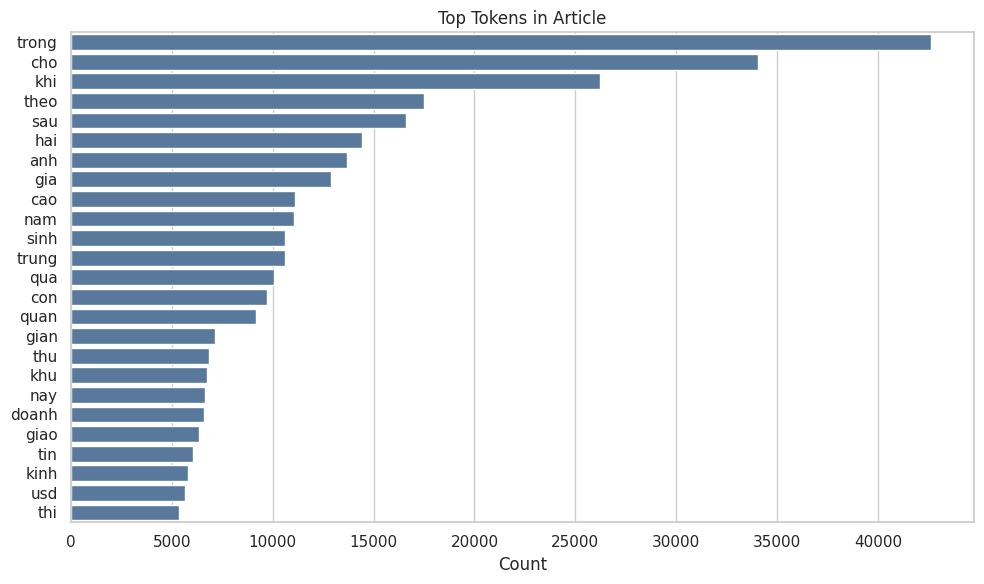

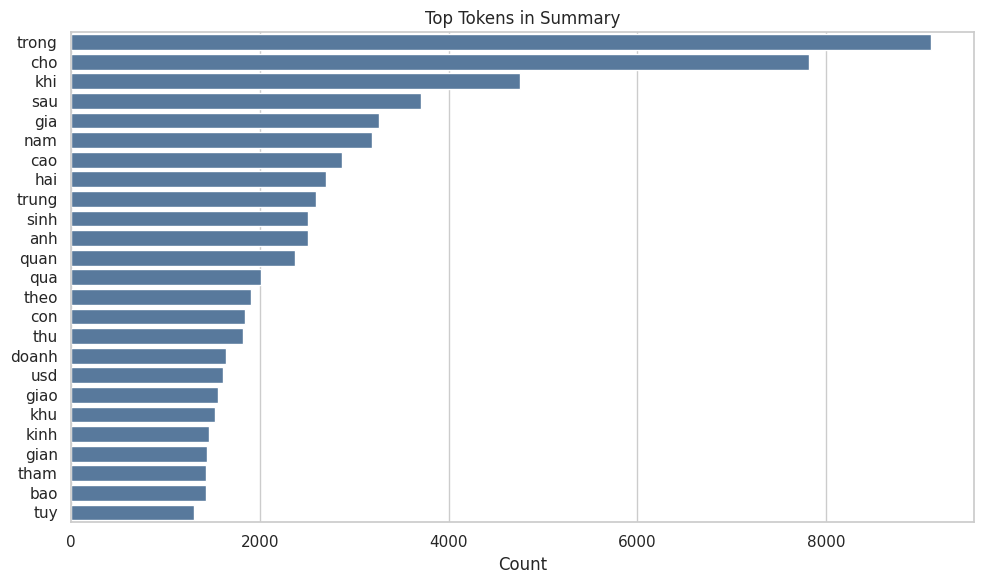

In [12]:
for col, table in token_tables.items():
    plt.figure(figsize=(10, 6))
    sns.barplot(data=table, y="token", x="count", color="#4C78A8")
    plt.title(f"Top Tokens in {col.title()}")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

## Optional: Compare Train and Validation

If `data/val.parquet` is present, this quick comparison checks whether validation has similar length distributions.

split                       train          val
article_words count  10775.000000  1349.000000
              mean     462.993132   471.314307
              std       99.882899   102.937972
              min      280.000000   296.000000
              25%      386.000000   395.000000
              50%      449.000000   455.000000
              75%      520.000000   536.000000
              max      737.000000   774.000000
summary_words count  10775.000000  1349.000000
              mean     103.769838   103.292068
              std       21.886020    22.017509
              min       50.000000    54.000000
              25%       87.000000    86.000000
              50%      101.000000   101.000000
              75%      119.000000   119.000000
              max      172.000000   164.000000

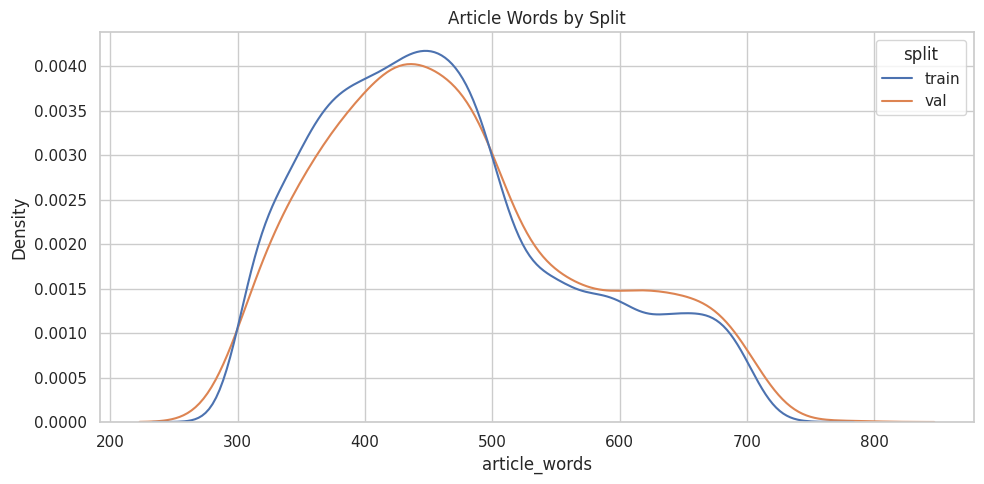

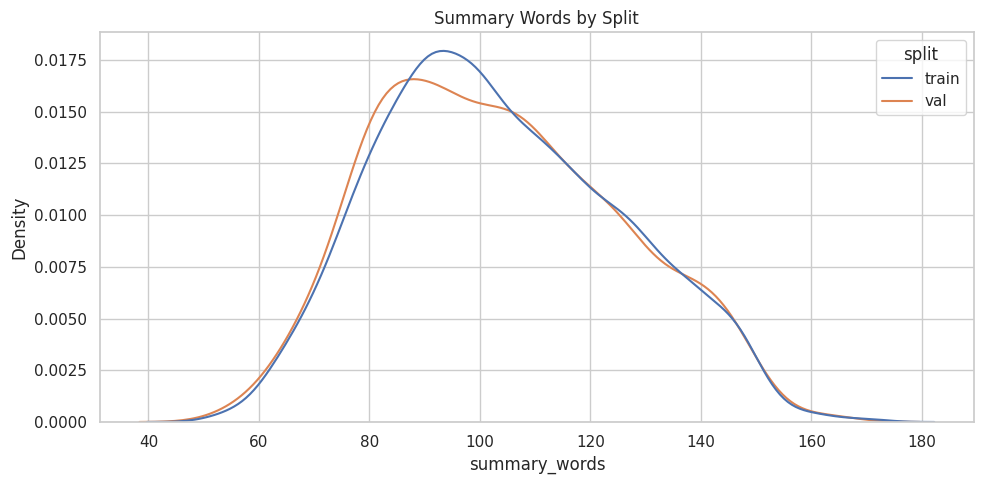

In [13]:
try:
    val_path = find_data_path("val.parquet")
    val = pd.read_parquet(val_path)
    val_eda = val.copy()
    if "article" in val_eda.columns:
        val_eda["article_words"] = word_count(val_eda["article"])
    if "summary" in val_eda.columns:
        val_eda["summary_words"] = word_count(val_eda["summary"])

    comparison = pd.concat(
        [
            eda.assign(split="train"),
            val_eda.assign(split="val"),
        ],
        ignore_index=True,
    )

    display(comparison.groupby("split")[[col for col in ["article_words", "summary_words"] if col in comparison.columns]].describe().T)

    for col in ["article_words", "summary_words"]:
        if col in comparison.columns:
            plt.figure(figsize=(10, 5))
            sns.kdeplot(data=comparison, x=col, hue="split", common_norm=False)
            plt.title(f"{col.replace('_', ' ').title()} by Split")
            plt.tight_layout()
            plt.show()
except FileNotFoundError:
    print("Validation parquet was not found; skipping split comparison.")

## Notes to Fill After Running

- Dataset size:
- Missing or empty text fields:
- Duplicate rows or repeated articles:
- Typical article and summary length:
- Outliers to inspect before modeling:
- Whether train and validation distributions look aligned: